In [1]:
# Import

In [33]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import random
import math

In [34]:
h.load_file('stdrun.hoc')

1.0

# create nodes

In [35]:
# ---------- РЕЕСТР, чтобы секции не удалялись GC ----------
REG = {"node": [], "mysa": [], "flut": [], "stin": []}
_node_id = _mysa_id = _flut_id = _stin_id = 0

def reset_model():
    # удалить все секции из ядра NEURON
    h('forall delete_section()')
    # обнулить наши реестры и счётчики
    REG["node"].clear(); REG["mysa"].clear(); REG["flut"].clear(); REG["stin"].clear()
    global _node_id, _mysa_id, _flut_id, _stin_id
    _node_id = _mysa_id = _flut_id = _stin_id = 0

reset_model()
# ---------- ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ ----------
CELSIUS = 37.0
DT_MS   = 0.05
V_INIT  = -80.0

# Электрические константы, как в MRG
rhoa = 0.7e6  # Ohm·um
mycm = 0.1    # uF/cm2 per lamella
mygm = 0.001  # S/cm2 per lamella

# Периакисональные зазоры (ум)
space_p1 = 0.002  # вокруг узла/MYSA
space_p2 = 0.004  # вокруг FLUT
space_i  = 0.004  # вокруг STIN

# Геометрия "минимал" MRG
paralength1 = 3.0   # MYSA длина (ум)
nodelength  = 1.0   # узел (ум)

gna_axnode = 3.0 # Проводимость
bouton_L = 1 # мкм
num_branching = 1


# Таблица MRG (как в твоём HOC)
MRG_TABLE = {
    5.7:  (0.605, 3.4, 1.9, 1.9, 3.4,  500, 35,  80),
    7.3:  (0.630, 4.6, 2.4, 2.4, 4.6,  750, 38, 100),
    8.7:  (0.661, 5.8, 2.8, 2.8, 5.8, 1000, 40, 110),
    10.0: (0.690, 6.9, 3.3, 3.3, 6.9, 1150, 46, 120),
    11.5: (0.700, 8.1, 3.7, 3.7, 8.1, 1250, 50, 130),
    12.8: (0.719, 9.2, 4.2, 4.2, 9.2, 1350, 54, 135),
    14.0: (0.739,10.4, 4.7, 4.7,10.4, 1400, 56, 140),
    15.0: (0.767,11.5, 5.0, 5.0,11.5, 1450, 58, 145),
    16.0: (0.791,12.7, 5.5, 5.5,12.7, 1500, 60, 150),
}

#   fiberD: (g, axonD, nodeD, paraD1, paraD2, deltax, paralength2, nl)

# ---------- ПАРАМЕТРЫ MRG НА ОСНОВЕ ВЫБРАННОГО fiberD ----------
def mrg_params(fiberD=5.7):
    if fiberD not in MRG_TABLE:
        raise ValueError(f"fiberD {fiberD} не в таблице.")
    g, axonD, nodeD, paraD1, paraD2, deltax, paralength2, nl = MRG_TABLE[fiberD]
    interlength = (deltax - nodelength - 2*paralength1 - 2*paralength2)/6.0
    Rpn0 = rin_peri(rhoa, nodeD,  space_p1)
    Rpn1 = rin_peri(rhoa, paraD1, space_p1)
    Rpn2 = rin_peri(rhoa, paraD2, space_p2)
    Rpx  = rin_peri(rhoa, axonD,  space_i)
    Lstep = 2*paralength1 + 2*paralength2 + 6*interlength + nodelength
    return dict(fiberD=fiberD, axonD=axonD, nodeD=nodeD,
                paraD1=paraD1, paraD2=paraD2,
                paral1=paralength1, paral2=paralength2,
                interL=interlength, nl=nl,
                Rpn0=Rpn0, Rpn1=Rpn1, Rpn2=Rpn2, Rpx=Rpx, Lstep=Lstep)



In [36]:
def rin_peri(rhoa_ohmum, inner_d_um, gap_um):
    """Продольное сопротивление периакисонального пространства для extracellular.xraxial."""
    return (rhoa_ohmum*0.01)/(math.pi*(((inner_d_um/2+gap_um)**2) - (inner_d_um/2)**2))

def ins(sec, mech: str):
    """Вставляет механизм, если его ещё нет."""
    if int(h.ismembrane(mech, sec=sec)) == 0:
        sec.insert(mech)

def set_extr(sec, xraxial, xg, xc):
    """extracellular-параметры: обязательно с индексом [0]."""
    ins(sec, 'extracellular')
    for seg in sec:
        seg.xraxial[0] = xraxial
        seg.xg[0]      = xg
        seg.xc[0]      = xc


def pick_node_mech():
    """Автовыбор доступного нодального механизма."""
    tmp = h.Section()
    try:
        tmp.insert('newaxnode'); tmp.uninsert('newaxnode')
        return 'newaxnode'
    except:
        pass
    try:
        tmp.insert('axnode'); tmp.uninsert('axnode')
        return 'axnode'
    except:
        pass
    raise RuntimeError("Не найден ни 'newaxnode', ни 'axnode' — скомпилируйте .mod.")

NODE_MECH = pick_node_mech()


In [37]:

# ---------- КОНСТРУКТОРЫ СЕКЦИЙ ----------
def make_node(nodeD, nodel, rhoa, Rpn0, node_mech=None,
              gnabar=None, gnapbar=None, el=None):
    global _node_id
    s = h.Section(name=f'node_{_node_id}'); _node_id += 1
    s.nseg = 1
    s.L    = nodel
    s.diam = nodeD
    s.Ra   = rhoa/10000.0
    s.cm   = 2.0
    mech   = node_mech or NODE_MECH
    ins(s, mech)
    if mech == 'newaxnode':
        s.el_newaxnode      = -90.0 if el is None else el
        s.gnabar_newaxnode  = 3.0   if gnabar  is None else gnabar
        s.gnapbar_newaxnode = 0.005 * 0.5 if gnapbar is None else gnapbar
    set_extr(s, Rpn0, 1e10, 0.0)
    REG["node"].append(s)
    return s

def make_mysa(fiberD, paraD1, paral1, rhoa, mygm, mycm, nl, Rpn1):
    global _mysa_id
    s = h.Section(name=f'MYSA_{_mysa_id}'); _mysa_id += 1
    s.nseg = 1
    s.L    = paral1
    s.diam = fiberD
    ratio  = paraD1/fiberD
    s.Ra   = rhoa*(1.0/(ratio*ratio))/10000.0
    s.cm   = 2.0*ratio
    ins(s, 'pas'); s.g_pas = 0.001*ratio; s.e_pas = -80.0
    set_extr(s, Rpn1, mygm/(nl*2.0), mycm/(nl*2.0))
    REG["mysa"].append(s)
    return s

def make_flut(fiberD, paraD2, paral2, rhoa, mygm, mycm, nl, Rpn2):
    global _flut_id
    s = h.Section(name=f'FLUT_{_flut_id}'); _flut_id += 1
    s.nseg = 1
    s.L    = paral2
    s.diam = fiberD
    ratio  = paraD2/fiberD
    s.Ra   = rhoa*(1.0/(ratio*ratio))/10000.0
    s.cm   = 2.0*ratio
    ins(s, 'pas'); s.g_pas = 0.0001*ratio; s.e_pas = -80.0
    set_extr(s, Rpn2, mygm/(nl*2.0), mycm/(nl*2.0))
    REG["flut"].append(s)
    return s

def make_stin(fiberD, axonD, interL, rhoa, mygm, mycm, nl, Rpx):
    global _stin_id
    s = h.Section(name=f'STIN_{_stin_id}'); _stin_id += 1
    s.nseg = 1
    s.L    = interL
    s.diam = fiberD
    ratio  = axonD/fiberD
    s.Ra   = rhoa*(1.0/(ratio*ratio))/10000.0
    s.cm   = 2.0*ratio
    ins(s, 'pas'); s.g_pas = 0.0001*ratio; s.e_pas = -80.0
    set_extr(s, Rpx, mygm/(nl*2.0), mycm/(nl*2.0))
    REG["stin"].append(s)
    return s

In [38]:
# ---------- ОДИН ШАГ MRG (между узлами): MYSA→FLUT→STIN×6→FLUT→MYSA→node ----------
def append_one_step(parent_node,P, node_mech=None):
    mysa0 = make_mysa(P['fiberD'], P['paraD1'], P['paral1'], rhoa, mygm, mycm, P['nl'], P['Rpn1'])
    flut0 = make_flut(P['fiberD'], P['paraD2'], P['paral2'], rhoa, mygm, mycm, P['nl'], P['Rpn2'])
    st = [make_stin(P['fiberD'], P['axonD'], P['interL'], rhoa, mygm, mycm, P['nl'], P['Rpx']) for _ in range(6)]
    flut1 = make_flut(P['fiberD'], P['paraD2'], P['paral2'], rhoa, mygm, mycm, P['nl'], P['Rpn2'])
    mysa1 = make_mysa(P['fiberD'], P['paraD1'], P['paral1'], rhoa, mygm, mycm, P['nl'], P['Rpn1'])
    nxt   = make_node(P['nodeD'], nodelength, rhoa, P['Rpn0'], node_mech=node_mech or NODE_MECH)

    # топология
    mysa0.connect(parent_node, 1.0, 0.0)
    flut0.connect(mysa0,       1.0, 0.0)
    st[0].connect(flut0,       1.0, 0.0)
    for k in range(1,6):
        st[k].connect(st[k-1], 1.0, 0.0)
    flut1.connect(st[5],       1.0, 0.0)
    mysa1.connect(flut1,       1.0, 0.0)
    nxt.connect(mysa1,         1.0, 0.0)
    return nxt

def build_chain(n_nodes, P, node_mech=None):
    nodes = [make_node(P['nodeD'], nodelength, rhoa, P['Rpn0'], node_mech=node_mech or NODE_MECH)]
    for _ in range(n_nodes-1):
        nxt = append_one_step(nodes[-1], P, node_mech=node_mech or NODE_MECH)
        nodes.append(nxt)
    return nodes

In [39]:
#h.topology()

def sinus_current(stim, amp_nA, f_hz, t_start_ms, t_stop_ms, phase_deg=0.0, dt_ms=None):
    if dt_ms is None:
        dt_ms = float(h.dt) if h.dt > 0 else 0.025
    t = np.arange(t_start_ms, t_stop_ms + dt_ms, dt_ms)
    w = 2*np.pi*f_hz/1000.0  # рад/мс
    phi = np.deg2rad(phase_deg)
    a = amp_nA * np.sin(w*(t - t_start_ms) + phi)

    tvec = h.Vector(t.tolist())
    avec = h.Vector(a.tolist())
    stim.delay = 0; stim.dur = 1e9; stim.amp = 0.0
    # равномерная сетка -> можно play по dt
    avec.play(stim._ref_amp, dt_ms)
    return tvec, avec

def pulse_train(stim, f_hz, n_pulses, amp_nA, pw_ms, start_ms=1.0):
    """
    Поезд импульсов частоты f_hz (период T=1000/f), n_pulses штук,
    каждым импульсом ширины pw_ms и амплитуды amp_nA.
    """
    T = 1000.0 / float(f_hz)  # период в мс
    tpts = [0.0]
    apts = [0.0]
    t = start_ms
    for _ in range(n_pulses):
        # фронт
        tpts.append(t);      apts.append(amp_nA)
        # спад
        tpts.append(t+pw_ms); apts.append(0.0)
        t += T
    # небольшая «хвостовая» точка, чтобы удержать ноль
    tpts.append(t + 1e-9); apts.append(0.0)

    tvec = h.Vector(tpts); avec = h.Vector(apts)
    stim.delay = 0; stim.dur = 1e9; stim.amp = 0.0
    avec.play(stim._ref_amp, tvec, 1)
    return tvec, avec



In [40]:
# ---------- ОДИН ШАГ MRG (между узлами): MYSA→FLUT→STIN×6→FLUT→MYSA→node ----------
def append_one_step(parent_node, P, node_mech=None):
        
    mysa0 = make_mysa(P['fiberD'], P['paraD1'], P['paral1'], rhoa, mygm, mycm, P['nl'], P['Rpn1'])
    flut0 = make_flut(P['fiberD'], P['paraD2'], P['paral2'], rhoa, mygm, mycm, P['nl'], P['Rpn2'])
    st = [make_stin(P['fiberD'], P['axonD'], P['interL'], rhoa, mygm, mycm, P['nl'], P['Rpx']) for _ in range(6)]
    flut1 = make_flut(P['fiberD'], P['paraD2'], P['paral2'], rhoa, mygm, mycm, P['nl'], P['Rpn2'])
    mysa1 = make_mysa(P['fiberD'], P['paraD1'], P['paral1'], rhoa, mygm, mycm, P['nl'], P['Rpn1'])
    nxt   = make_node(P['nodeD'], nodelength, rhoa, P['Rpn0'], node_mech=node_mech or NODE_MECH)

    # топология
    mysa0.connect(parent_node, 1.0, 0.0)
    flut0.connect(mysa0,       1.0, 0.0)
    st[0].connect(flut0,       1.0, 0.0)
    for k in range(1,6):
        st[k].connect(st[k-1], 1.0, 0.0)
    flut1.connect(st[5],       1.0, 0.0)
    mysa1.connect(flut1,       1.0, 0.0)
    nxt.connect(mysa1,         1.0, 0.0)
        
        
    return nxt

def build_chain(n_nodes, P, node_mech=None):
    nodes = [make_node(P['nodeD'], nodelength, rhoa, P['Rpn0'], node_mech=node_mech or NODE_MECH)]
    for _ in range(n_nodes-1):
        nxt = append_one_step(nodes[-1], P, node_mech=node_mech or NODE_MECH)
        nodes.append(nxt)
    return nodes

In [41]:
def scaled_params(P, diam_scale=0.6):
    """Сужение диаметров после ветвления."""
    out = dict(P)
    out['fiberD'] *= diam_scale
    out['axonD']  *= diam_scale
    out['nodeD']  *= diam_scale
    out['paraD1'] *= diam_scale
    out['paraD2'] *= diam_scale
    # длины оставляем как есть; при желании можно тоже масштабировать
    out['Rpn0'] = rin_peri(rhoa, out['nodeD'],  space_p1)
    out['Rpn1'] = rin_peri(rhoa, out['paraD1'], space_p1)
    out['Rpn2'] = rin_peri(rhoa, out['paraD2'], space_p2)
    out['Rpx']  = rin_peri(rhoa, out['axonD'],  space_i)
    # Lstep не меняем, если длины не масштабируем
    return out

reset_model()
terminals = []
diam_scale=0.6
h.celsius = CELSIUS
h.dt      = DT_MS

P0 = mrg_params(fiberD=10)
P_curr = dict(P0)
#print("P0", P0, "P_curr", P_curr)

main_axon = [make_node(P_curr['nodeD'], nodelength, rhoa, P_curr['Rpn0'], NODE_MECH)]

node_D_after_branching = False
count_nodes_after_branching = 0

parent_axon_nodes = 42
branch_nodes = 21
branches_num = 2
nodes_dist = 10
nodes = 0

branch_point_id = []
before_branch_id = []
after_branch_main_id = []
after_branch_daughter_id = []

for _ in range(parent_axon_nodes-1):

    if node_D_after_branching == True:

        P_main_axon = scaled_params(P_curr, diam_scale=diam_scale)
        nxt = append_one_step(main_axon[-1], P_main_axon, node_mech=NODE_MECH)
        main_axon.append(nxt)
        # вставляем 1 шаг со скейлом на 60 % 

        count_nodes_after_branching -= 1
        print(f"count_nodes_after_branching: {count_nodes_after_branching}")
        if count_nodes_after_branching == 0: 
            node_D_after_branching = False
            after_branch_main_id.extend(main_axon[-1])
            
    if node_D_after_branching == False:
        
        nxt = append_one_step(main_axon[-1], P_curr, node_mech=NODE_MECH)
        main_axon.append(nxt)

    nodes +=1
    #print(nodes)
    # Надо высчитать длину типичного шага при append one step, но через ноды удобнее. 
    # TODO через вычисления длины нод сделать ветвление через какие-то промежутки
    if nodes >= nodes_dist and branches_num != 0: 
        print(f"Ветвление с шагом в: {nodes} нод")

        branch_point_id.extend(main_axon[-1])
        #before_branch_id += noedes - 3
        if len(main_axon) >= 3:
            before_branch_id.extend(main_axon[-3])
        else:
            before_branch_id.extend(main_axon[-1])


        node_2 = make_node(P_curr['nodeD'], nodelength, rhoa, P_curr['Rpn0'], node_mech=NODE_MECH)
        node_2.connect(main_axon[-1], 1.0, 0.0)
        
        # Создаем дочернюю ветвь
        P_branch = scaled_params(P_curr, diam_scale=diam_scale)
        term_chain = build_chain(branch_nodes, P_branch, node_mech=NODE_MECH)
        term_chain[0].connect(node_2, 0.0, 1.0)
        #after_branch_daughter_id += term_chain + 3

        if len(term_chain) >= 3:
            after_branch_daughter_id.extend(term_chain[3])
        else:
            after_branch_daughter_id.extend(term_chain[-1])

        # Продолжение основного аксона
        node_3 = make_node(P_curr['nodeD'], nodelength, rhoa, P_curr['Rpn0'], node_mech=NODE_MECH)
        node_3.connect(node_2, 1.0, 0.0)

        #after_branch_main_id += node_3 + 3

        # ИСПРАВЛЕННАЯ ОТЛАДОЧНАЯ ПЕЧАТЬ:
        print(f"Ветвление: {main_axon[-1].name()} -> {node_2.name()}")
        print(f"  Ветвь: {node_2.name()} -> {term_chain[0].name()}")
        print(f"  Продолжение: {node_2.name()} -> {node_3.name()}")
        
        terminals.append(node_2)
        main_axon.append(node_3)
        node_D_after_branching = True
        branches_num -= 1
        nodes = 0
        count_nodes_after_branching = 3




        

Ветвление с шагом в: 10 нод
Ветвление: node_10 -> node_11
  Ветвь: node_11 -> node_12
  Продолжение: node_11 -> node_33
count_nodes_after_branching: 2
count_nodes_after_branching: 1
count_nodes_after_branching: 0
Ветвление с шагом в: 10 нод
Ветвление: node_44 -> node_45
  Ветвь: node_45 -> node_46
  Продолжение: node_45 -> node_67
count_nodes_after_branching: 2
count_nodes_after_branching: 1
count_nodes_after_branching: 0


In [42]:
print(branch_point_id, before_branch_id, after_branch_main_id, after_branch_daughter_id)

[node_10(0.5), node_44(0.5)] [node_8(0.5), node_42(0.5)] [node_36(0.5), node_70(0.5)] [node_15(0.5), node_49(0.5)]


In [43]:
def check_branching():
    for sec in h.allsec():
        parent = sec.parentseg()
        if parent:
            parent_sec = parent.sec
            children = []
            for child in h.allsec():
                if hasattr(child, 'parentseg') and child.parentseg():
                    if child.parentseg().sec == sec:
                        children.append(child.name())
            if len(children) > 1:
                print(f"ВЕТВЛЕНИЕ: {sec.name()} -> {children}")

check_branching()

ВЕТВЛЕНИЕ: node_11 -> ['node_12', 'node_33']
ВЕТВЛЕНИЕ: node_45 -> ['node_46', 'node_67']


In [44]:
main_axon

[node_0,
 node_1,
 node_2,
 node_3,
 node_4,
 node_5,
 node_6,
 node_7,
 node_8,
 node_9,
 node_10,
 node_33,
 node_34,
 node_35,
 node_36,
 node_37,
 node_38,
 node_39,
 node_40,
 node_41,
 node_42,
 node_43,
 node_44,
 node_67,
 node_68,
 node_69,
 node_70,
 node_71,
 node_72,
 node_73,
 node_74,
 node_75,
 node_76,
 node_77,
 node_78,
 node_79,
 node_80,
 node_81,
 node_82,
 node_83,
 node_84,
 node_85,
 node_86,
 node_87,
 node_88,
 node_89]

# Set stimulus


In [20]:
print(main_axon[0].psection()['density_mechs'].keys())

dict_keys(['extracellular', 'newaxnode'])


In [21]:
main_axon[0].psection()['density_mechs']['axnode'].keys()

KeyError: 'axnode'

In [22]:
main_axon[0].psection()['density_mechs']['axnode']['ina']

KeyError: 'axnode'

In [23]:
dir(main_axon[0])

['L',
 'Ra',
 '__call__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'allseg',
 'arc3d',
 'cell',
 'children',
 'connect',
 'diam3d',
 'disconnect',
 'has_membrane',
 'hname',
 'hoc_internal_name',
 'insert',
 'is_pysec',
 'n3d',
 'name',
 'nseg',
 'orientation',
 'parentseg',
 'psection',
 'pt3dadd',
 'pt3dchange',
 'pt3dclear',
 'pt3dinsert',
 'pt3dremove',
 'pt3dstyle',
 'push',
 'rallbranch',
 'same',
 'spine3d',
 'subtree',
 'trueparentseg',
 'uninsert',
 'wholetree',
 'x3d',
 'y3d',
 'z3d']

In [24]:
main_axon[0].psection()

{'point_processes': {},
 'density_mechs': {'extracellular': {'xraxial': [[337396.9114607195,
     1000000000.0]],
   'xg': [[10000000000.0, 1000000000.0]],
   'xc': [[0.0, 0.0]],
   'e': [0.0],
   'i_membrane': [0.0],
   'vext': [[0.0, 0.0]]},
  'newaxnode': {'gnapbar': [0.0025],
   'gnabar': [3.0],
   'gkbar': [0.08],
   'gl': [0.007],
   'ena': [50.0],
   'ek': [-90.0],
   'el': [-90.0],
   'inap': [0.0],
   'ina': [0.0],
   'ik': [0.0],
   'il': [0.0],
   'mp_inf': [0.0],
   'm_inf': [0.0],
   'h_inf': [0.0],
   's_inf': [0.0],
   'tau_mp': [0.0],
   'tau_m': [0.0],
   'tau_h': [0.0],
   'tau_s': [0.0],
   'mp': [0.0],
   'm': [0.0],
   'h': [0.0],
   's': [0.0]}},
 'ions': {},
 'morphology': {'L': 1.0,
  'diam': [3.3],
  'pts3d': [],
  'parent': None,
  'trueparent': None},
 'nseg': 1,
 'Ra': 70.0,
 'cm': [2.0],
 'regions': set(),
 'species': set(),
 'name': 'node_0',
 'hoc_internal_name': '__nrnsec_00000150014a8f90',
 'cell': None}

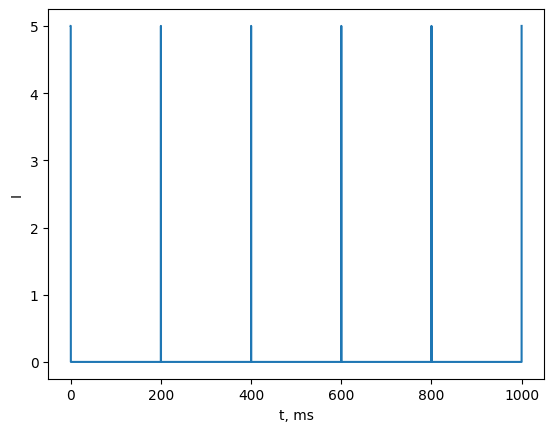

In [50]:

freq_hz = 100              # Гц
T_ms = 1000.0 / freq_hz  # период, мс (200 мс)
amp = 5
dt_ms = 0.01             # шаг, мс (напр. 0.01 мс)
t_start = 0.0            # мс
t_end = 1000.0           # мс (сделаем 1 c, чтобы увидеть импульсы)
pulse_len_ms = 0.1       # длительность импульса, мс
phase_ms = 0.0           # сдвиг старта пачки, мс

t = np.arange(t_start, t_end + 0.5*dt_ms, dt_ms)
stim = np.zeros_like(t)

stim = np.zeros_like(t)
n_pulses = int(np.floor((t_end - (t_start + phase_ms)) / T_ms)) + 1
for k in range(max(0, n_pulses)):
    t0 = t_start + phase_ms + k*T_ms
    t1 = t0 + pulse_len_ms
    if t0 > t_end: break
    on = (t >= t0) & (t < t1)
    stim[on] = amp



plt.plot(t, stim)
plt.xlabel('t, ms'); plt.ylabel('I')
plt.show()


In [26]:
#iclamp = n.IClamp(soma(0.5))

#inj = h.IClamp(main_axon[0](0.5))

inj_sec = main_axon[0]


# Создание стимулятора
stim = h.IClamp(inj_sec(0.5))

# Создание временного вектора и вектора тока
time_vec = h.Vector()
current_vec = h.Vector()

# Генерация формы сигнала
t_points = np.arange(0, t_end + dt_ms, dt_ms)
i_points = np.zeros(len(t_points))

# Расчет количества импульсов
n_pulses = int(np.floor((t_end - (t_start + phase_ms)) / T_ms)) + 1


In [27]:
print(f"n_pulses: {n_pulses}")
print(f"t_points: {t_points}")
# Заполнение импульсов
for k in range(n_pulses):
    t0 = t_start + phase_ms + k * T_ms
    t1 = t0 + pulse_len_ms
    print(f"t0: {t0}")
    print(f"t1: {t1}")
    if t0 > t_end:
        break
    # Находим индексы для включения импульса
    mask = (t_points >= t0) & (t_points < t1)
    print(f"mask: {mask}")
    print(f"(t_points >= t0) & (t_points < t1): {(t_points+ t0 >= t0) & (t_points+ t0 < t1)}")
    i_points[mask] = amp

# Конвертируем numpy arrays в NEURON Vectors
time_vec.from_python(t_points)
current_vec.from_python(i_points)

# Подключаем форму тока к стимулятору
current_vec.play(stim._ref_amp, time_vec, 1)

print(f"i_points: {np.where(i_points == 0.1)}")

n_pulses: 251
t_points: [0.0000e+00 1.0000e-02 2.0000e-02 ... 9.9998e+02 9.9999e+02 1.0000e+03]
t0: 0.0
t1: 1.0
mask: [ True  True  True ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 4.0
t1: 5.0
mask: [False False False ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 8.0
t1: 9.0
mask: [False False False ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 12.0
t1: 13.0
mask: [False False False ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 16.0
t1: 17.0
mask: [False False False ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 20.0
t1: 21.0
mask: [False False False ... False False False]
(t_points >= t0) & (t_points < t1): [ True  True  True ... False False False]
t0: 24.0
t1: 25.0
mask: [False False False ...

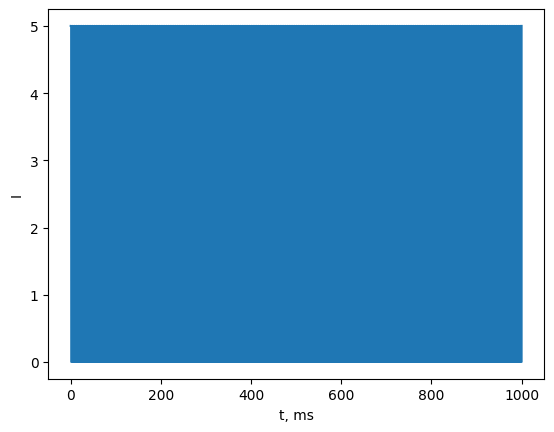

In [28]:

plt.plot(t_points, i_points)
plt.xlabel('t, ms'); plt.ylabel('I')
plt.show()

In [37]:

# Удаляем старый стимулятор если был
if 'stim' in locals():
    stim = None

# Создаем последовательность импульсов
stims = []
for k in range(n_pulses):
    t0 = t_start + phase_ms + k * T_ms
    if t0 > t_end:
        break

    stim = h.IClamp(inj_sec(0.5))
    stim.delay = t0
    stim.dur = pulse_len_ms
    stim.amp = amp
    stims.append(stim)  # сохраняем ссылку

In [30]:
# Проверка что стимул создан
print(f"Stimulator: {stim}")
print(f"Section: {inj_sec}")
print(f"Location: {inj_sec(0.5)}")

# Проверка векторов
print(f"Time vector size: {time_vec.size()}")
print(f"Current vector size: {current_vec.size()}")

# Проверка первых нескольких значений
print("First 10 time points:", time_vec.to_python()[:10])
print("First 10 current points:", current_vec.to_python()[:10])

Stimulator: IClamp[250]
Section: node_0
Location: node_0(0.5)
Time vector size: 100001
Current vector size: 100001
First 10 time points: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
First 10 current points: [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [31]:
h.run()
record_v = []
record_t = []
i = 0
for _ in REG["node"]:
    vec = h.Vector().record(main_axon[i](0.5)._ref_v)
    t = h.Vector().record(h._ref_t)
    record_t.append(t)
    record_v.append(vec)
    i+1
# Пишем потенциал на первом терминале
#t = h.Vector().record(h._ref_t)

h.tstop = 1000.0
#h.finitialize(V_INIT)
h.run()
#time_array = np.array(t)
voltage_matrix = np.vstack([np.array(v) for v in record_v])  # shape: (Nnodes, Nt)
time_matrix = np.vstack([np.array(t) for t in record_t])



Changed dt


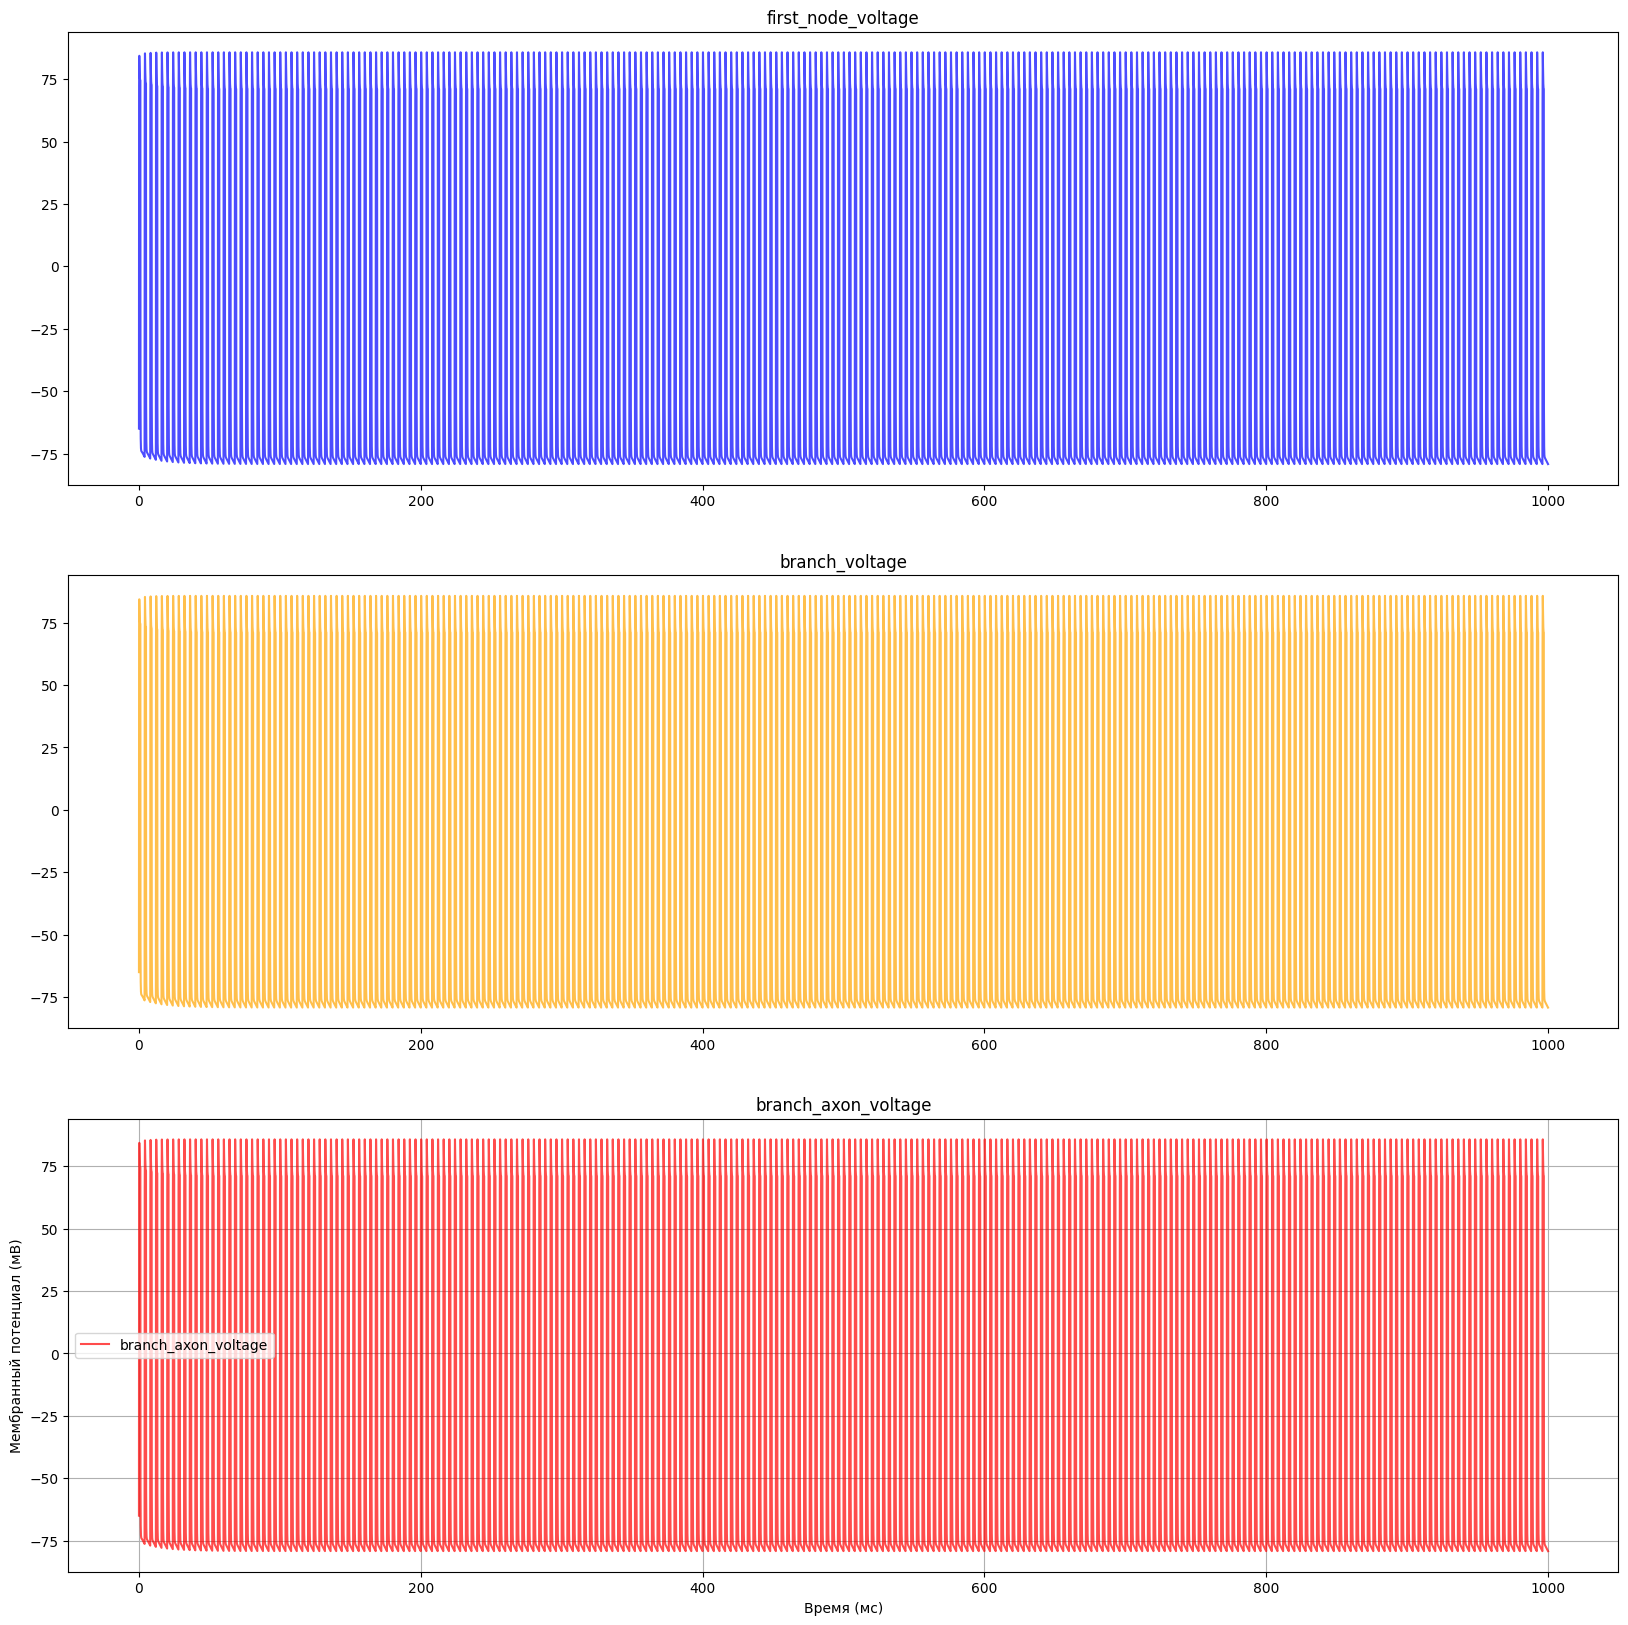

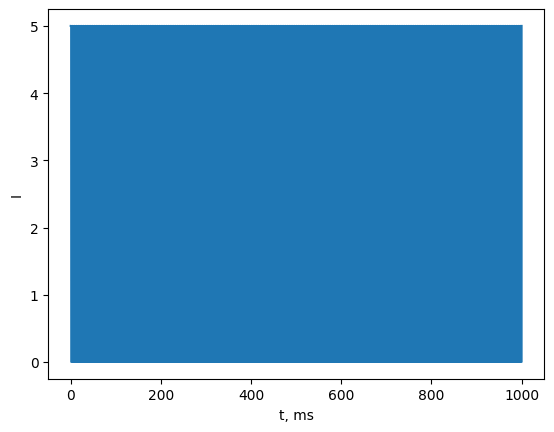

In [32]:
first_node_voltage = voltage_matrix[1]
branch_voltage = voltage_matrix[int(nodes_dist + 4)]
branch_axon_voltage = voltage_matrix[int(nodes_dist + branch_nodes + 4)]

first_node_t = time_matrix[1]
branch_t = time_matrix[int(nodes_dist + 4)]
branch_axon_t = time_matrix[int(nodes_dist + branch_nodes + 4)]


fig, axes = plt.subplots(
    3,               #одной строкой
    1,               #три графика
    figsize=(20, 20)  #вписать в размер 15х4 дюйма
)
axes[0].plot(first_node_t,first_node_voltage, alpha=0.7, label= f"first_node_voltage", color='blue')
axes[0].set_title(f'first_node_voltage')
axes[1].plot(branch_t,branch_voltage, alpha=0.7, label= f"branch_voltage", color='orange')
axes[1].set_title(f'branch_voltage')
axes[2].plot(branch_axon_t,branch_axon_voltage, alpha=0.7, label= f"branch_axon_voltage", color='red')
axes[2].set_title(f'branch_axon_voltage')


plt.legend()
plt.xlabel("Время (мс)")
plt.ylabel("Мембранный потенциал (мВ)")
#plt.title("Ответ на стимуляцию в главном аксоне")
plt.grid(True)
plt.show()

plt.plot(t_points, i_points)
plt.xlabel('t, ms'); plt.ylabel('I')
plt.show()

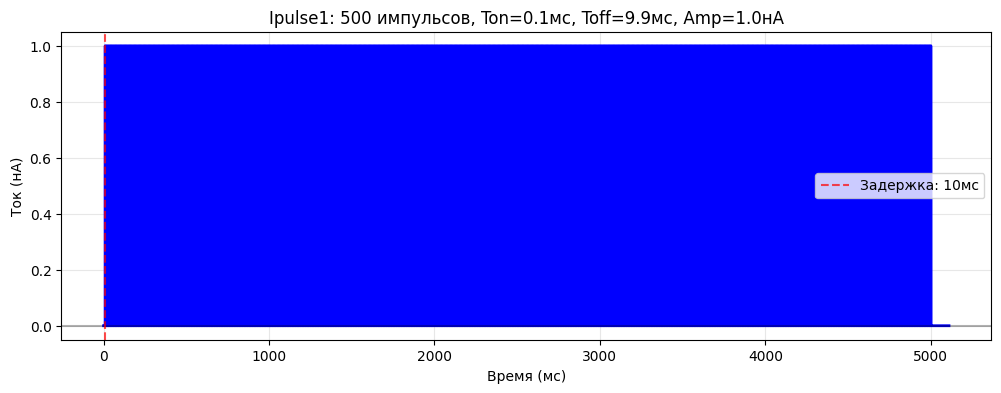

In [ ]:
from impulse_generator import *

# ПРАВИЛЬНОЕ объявление параметров (без запятых в конце):
del_val = 10     # задержка 10 мс
ton = 0.1        # длительность импульса 0.1 мс
toff = 9.9       # интервал 9.9 мс (период 10 мс = 100 Гц)
num = 500         # 50 импульсов
amp = 1.0        # амплитуда 1 нА

ipulse_stimulator = Ipulse1Stimulator(main_axon[0], position=0.5)
ipulse_stimulator.set_parameters(del_val, ton, toff, num, amp)

# Обновляем время симуляции чтобы покрыть все импульсы
total_time = del_val + num * (ton + toff) + 100
h.tstop = total_time  # ← ДОБАВЬТЕ ЭТУ СТРОЧКУ!

ipulse_stimulator.plot_waveform()

# Запись потенциалов - ИСПРАВЛЕННАЯ ВЕРСИЯ:
record_v = []
record_t = h.Vector().record(h._ref_t)  # один общий временной вектор

# Правильная запись по всем узлам:
for i, node_section in enumerate(main_axon):
    vec = h.Vector().record(node_section(0.5)._ref_v)
    record_v.append(vec)

h.finitialize(-80.0)  # ← ДОБАВЬТЕ ИНИЦИАЛИЗАЦИЮ!
h.run()

# Преобразование данных
time_array = np.array(record_t)
voltage_matrix = np.vstack([np.array(v) for v in record_v])  # shape: (Nnodes, Nt)

# Выбираем нужные узлы для графиков
first_node_voltage = voltage_matrix[0]  # первый узел
branch_voltage = voltage_matrix[nodes_dist]  # узел в точке ветвления
branch_axon_voltage = voltage_matrix[nodes_dist + 1]  # следующий после ветвления

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(time_array, first_node_voltage, alpha=0.7, label="first_node_voltage", color='blue')
axes[0].set_title('Потенциал в первом узле')
axes[0].grid(True)

axes[1].plot(time_array, branch_voltage, alpha=0.7, label="branch_voltage", color='orange')
axes[1].set_title('Потенциал в точке ветвления')
axes[1].grid(True)

axes[2].plot(time_array, branch_axon_voltage, alpha=0.7, label="branch_axon_voltage", color='red')
axes[2].set_title('Потенциал после ветвления')
axes[2].grid(True)

plt.xlabel("Время (мс)")
plt.ylabel("Мембранный потенциал (мВ)")
plt.tight_layout()
plt.show()

# График стимуляции (если нужно)
t_points = np.array(ipulse_stimulator.time_vec)
i_points = np.array(ipulse_stimulator.current_vec)

plt.figure(figsize=(10, 3))
plt.plot(t_points, i_points)
plt.xlabel('t, ms')
plt.ylabel('I, nA')
plt.title('Протокол стимуляции')
plt.grid(True)
plt.show()

In [45]:
from impulse_generator import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def run_frequency_sweep(main_axon, nodes_dist, branch_nodes, frequencies, amp=1.0, num_pulses=50):
    """
    Запускает симуляцию для разных частот стимуляции и анализирует проведение через ветвление

    Parameters:
    main_axon: список секций главного аксона
    nodes_dist: расстояние до точки ветвления (в узлах)
    branch_nodes: количество узлов в ветви
    frequencies: список частот для тестирования (Гц)
    amp: амплитуда стимуляции (нА)
    num_pulses: количество импульсов в каждой серии
    """

    results = {
        'frequencies': frequencies,
        'before_branch_spikes': [],
        'after_main_spikes': [],
        'after_daughter_spikes': [],
        'main_conduction_ratio': [],
        'daughter_conduction_ratio': []
    }

    for freq in frequencies:
        print(f"Тестирование частоты: {freq} Гц")

        # Расчет параметров стимуляции
        T_ms = 1000.0 / freq  # период в мс
        ton = 0.1  # длительность импульса
        toff = T_ms - ton  # интервал между импульсами

        # Создаем стимулятор
        ipulse_stimulator = Ipulse1Stimulator(main_axon[0], position=0.5)
        ipulse_stimulator.set_parameters(del_val=10, ton=ton, toff=toff, num=num_pulses, amp=amp)

        # Обновляем время симуляции
        total_time = 10 + num_pulses * (ton + toff) + 100
        h.tstop = total_time

        # Запись потенциалов в ключевых точках
        record_v = []
        record_t = h.Vector().record(h._ref_t)

        # Записываем потенциалы в ключевых узлах:
        # 1. До ветвления (узлы до точки ветвления)
        # 2. В точке ветвления
        # 3. После ветвления в основной ветви
        # 4. После ветвления в дочерней ветви

        key_nodes = [
            main_axon[nodes_dist - 2],    # до ветвления
            main_axon[nodes_dist],        # точка ветвления
            main_axon[nodes_dist + 2],    # после ветвления (основная ветвь)
            main_axon[nodes_dist + branch_nodes + 2]  # после ветвления (дочерняя ветвь)
        ]

        for node in key_nodes:
            vec = h.Vector().record(node(0.5)._ref_v)
            record_v.append(vec)

        # Запускаем симуляцию
        h.finitialize(-80.0)
        h.run()

        # Анализ спайков
        time_array = np.array(record_t)
        voltage_data = [np.array(v) for v in record_v]

        # Подсчет спайков в каждой точке (порог -20 мВ)
        spike_counts = []
        for voltage in voltage_data:
            peaks, _ = find_peaks(voltage, height=-20, distance=int(2/0.05))  # минимум 2 мс между спайками
            spike_counts.append(len(peaks))

        # Сохраняем результаты
        results['before_branch_spikes'].append(spike_counts[0])
        results['after_main_spikes'].append(spike_counts[2])
        results['after_daughter_spikes'].append(spike_counts[3])

        # Вычисляем коэффициенты проведения
        if spike_counts[0] > 0:
            results['main_conduction_ratio'].append(spike_counts[2] / spike_counts[0])
            results['daughter_conduction_ratio'].append(spike_counts[3] / spike_counts[0])
        else:
            results['main_conduction_ratio'].append(0)
            results['daughter_conduction_ratio'].append(0)

        # Очистка для следующей итерации
        ipulse_stimulator = None
        #h('forall delete_section()')  # осторожно - это удалит все секции!

    return results

def plot_frequency_sweep_results(results, save_path=None):
    """Строит графики результатов частотного сканирования"""

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    frequencies = results['frequencies']

    # График 1: Количество спайков до ветвления
    ax1.semilogx(frequencies, results['before_branch_spikes'], 'bo-', linewidth=2, markersize=6)
    ax1.set_xlabel('Частота стимуляции (Гц)')
    ax1.set_ylabel('Количество спайков')
    ax1.set_title('Спайки до ветвления')
    ax1.grid(True, alpha=0.3)

    # График 2: Коэффициент проведения (основная ветвь)
    ax2.semilogx(frequencies, results['main_conduction_ratio'], 'ro-', linewidth=2, markersize=6, label='Основная ветвь')
    ax2.semilogx(frequencies, results['daughter_conduction_ratio'], 'go-', linewidth=2, markersize=6, label='Дочерняя ветвь')
    ax2.set_xlabel('Частота стимуляции (Гц)')
    ax2.set_ylabel('Коэффициент проведения')
    ax2.set_title('Проведение через ветвление')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 1.1)

    # График 3: Абсолютное количество спайков после ветвления
    ax3.semilogx(frequencies, results['after_main_spikes'], 'ro-', linewidth=2, markersize=6, label='Основная ветвь')
    ax3.semilogx(frequencies, results['after_daughter_spikes'], 'go-', linewidth=2, markersize=6, label='Дочерняя ветвь')
    ax3.set_xlabel('Частота стимуляции (Гц)')
    ax3.set_ylabel('Количество спайков')
    ax3.set_title('Спайки после ветвления')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # График 4: Разница в проведении между ветвями
    conduction_difference = np.array(results['main_conduction_ratio']) - np.array(results['daughter_conduction_ratio'])
    ax4.semilogx(frequencies, conduction_difference, 'purple', linewidth=2, markersize=6)
    ax4.set_xlabel('Частота стимуляции (Гц)')
    ax4.set_ylabel('Разница в проведении')
    ax4.set_title('Разница проведения: основная - дочерняя ветвь')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Графики сохранены: {save_path}")

    plt.show()

    return fig



In [32]:
main_axon

[<deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>,
 <deleted section>]

Тестирование частоты: 10 Гц
Changed dt
Тестирование частоты: 20 Гц
Тестирование частоты: 50 Гц
Тестирование частоты: 100 Гц
Тестирование частоты: 200 Гц
Тестирование частоты: 500 Гц
Тестирование частоты: 1000 Гц
Тестирование частоты: 2000 Гц
Тестирование частоты: 5000 Гц
Графики сохранены: frequency_sweep_results.png


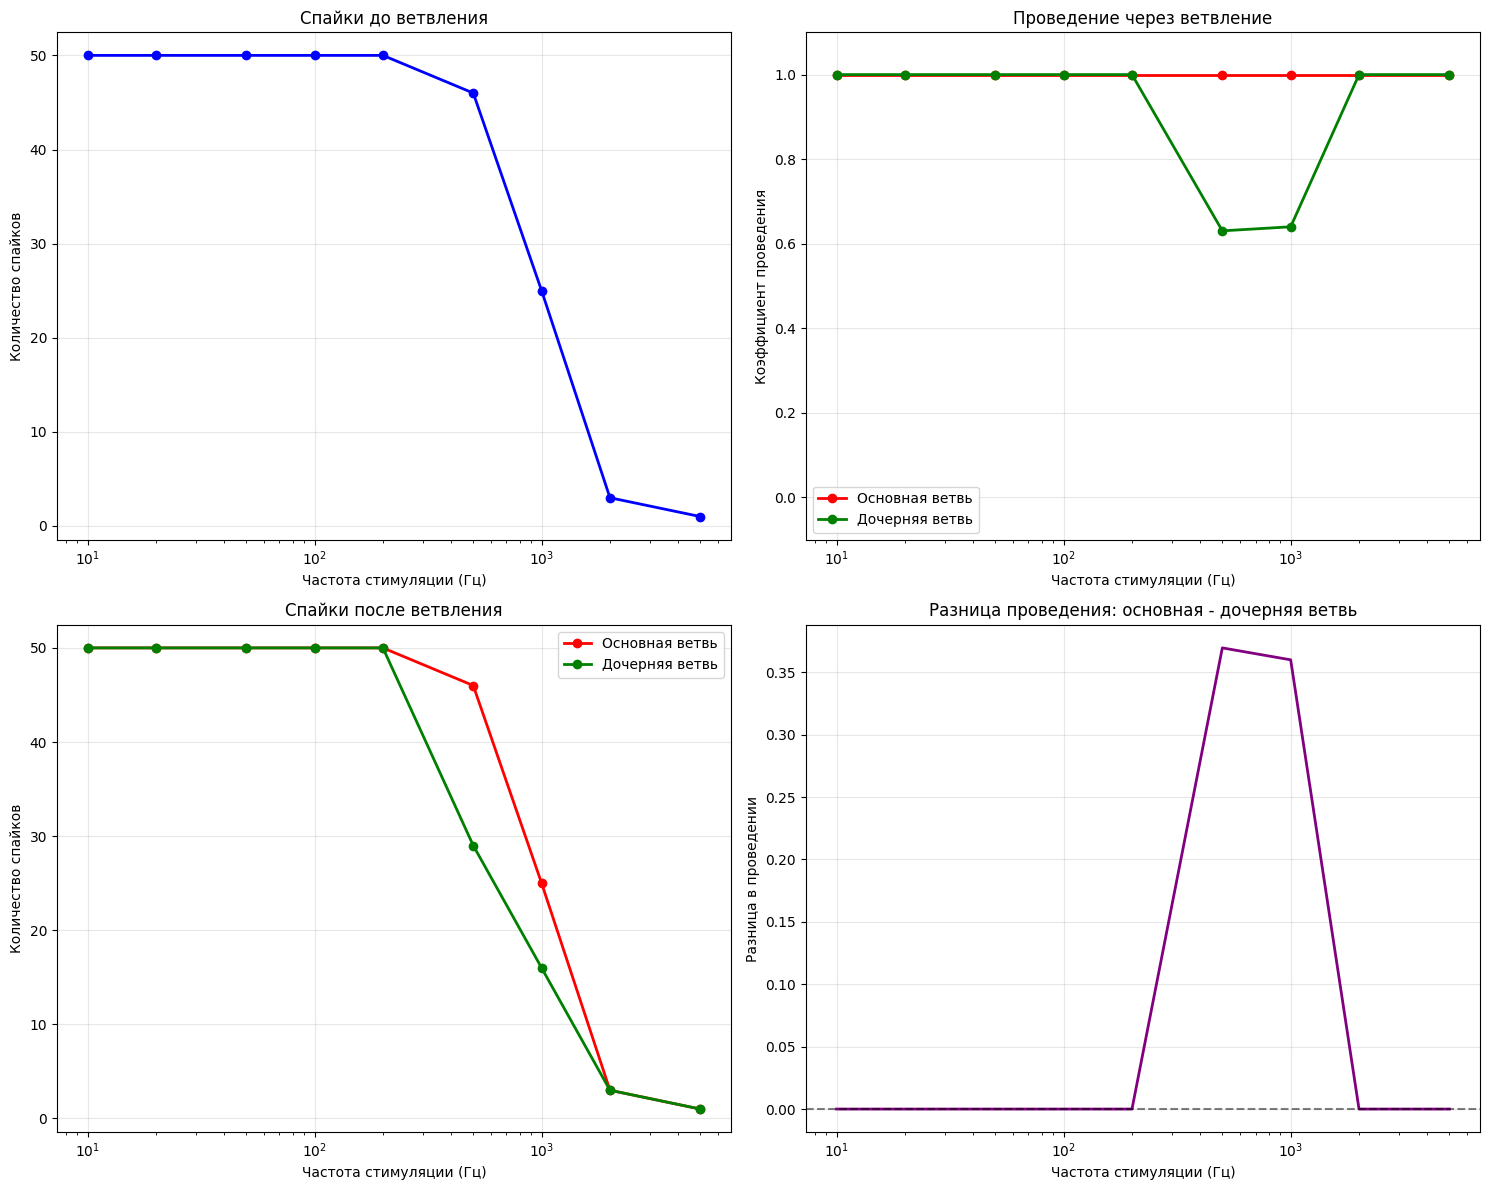

Частота блокады основной ветви: None Гц
Частота блокады дочерней ветви: None Гц


In [46]:

# Определяем диапазон частот для тестирования (как в статье)
frequencies = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

# Предполагая, что у вас уже создан аксон и определены параметры:
# main_axon = ... (ваш созданный аксон)
# nodes_dist = ... (расстояние до ветвления)
# branch_nodes = ... (количество узлов в ветви)

# Запускаем частотное сканирование
results = run_frequency_sweep(
    main_axon=main_axon,
    nodes_dist=nodes_dist,
    branch_nodes=branch_nodes,
    frequencies=frequencies,
    amp=1.0,
    num_pulses=50
)

# Строим графики
plot_frequency_sweep_results(results, save_path="frequency_sweep_results.png")

# Дополнительный анализ: находим частоту блокады
main_ratios = np.array(results['main_conduction_ratio'])
daughter_ratios = np.array(results['daughter_conduction_ratio'])

# Находим частоту, при которой проведение падает ниже 50%
main_block_freq = None
daughter_block_freq = None

for i, freq in enumerate(frequencies):
    if main_ratios[i] < 0.5 and main_block_freq is None:
        main_block_freq = freq
    if daughter_ratios[i] < 0.5 and daughter_block_freq is None:
        daughter_block_freq = freq

print(f"Частота блокады основной ветви: {main_block_freq} Гц")
print(f"Частота блокады дочерней ветви: {daughter_block_freq} Гц")

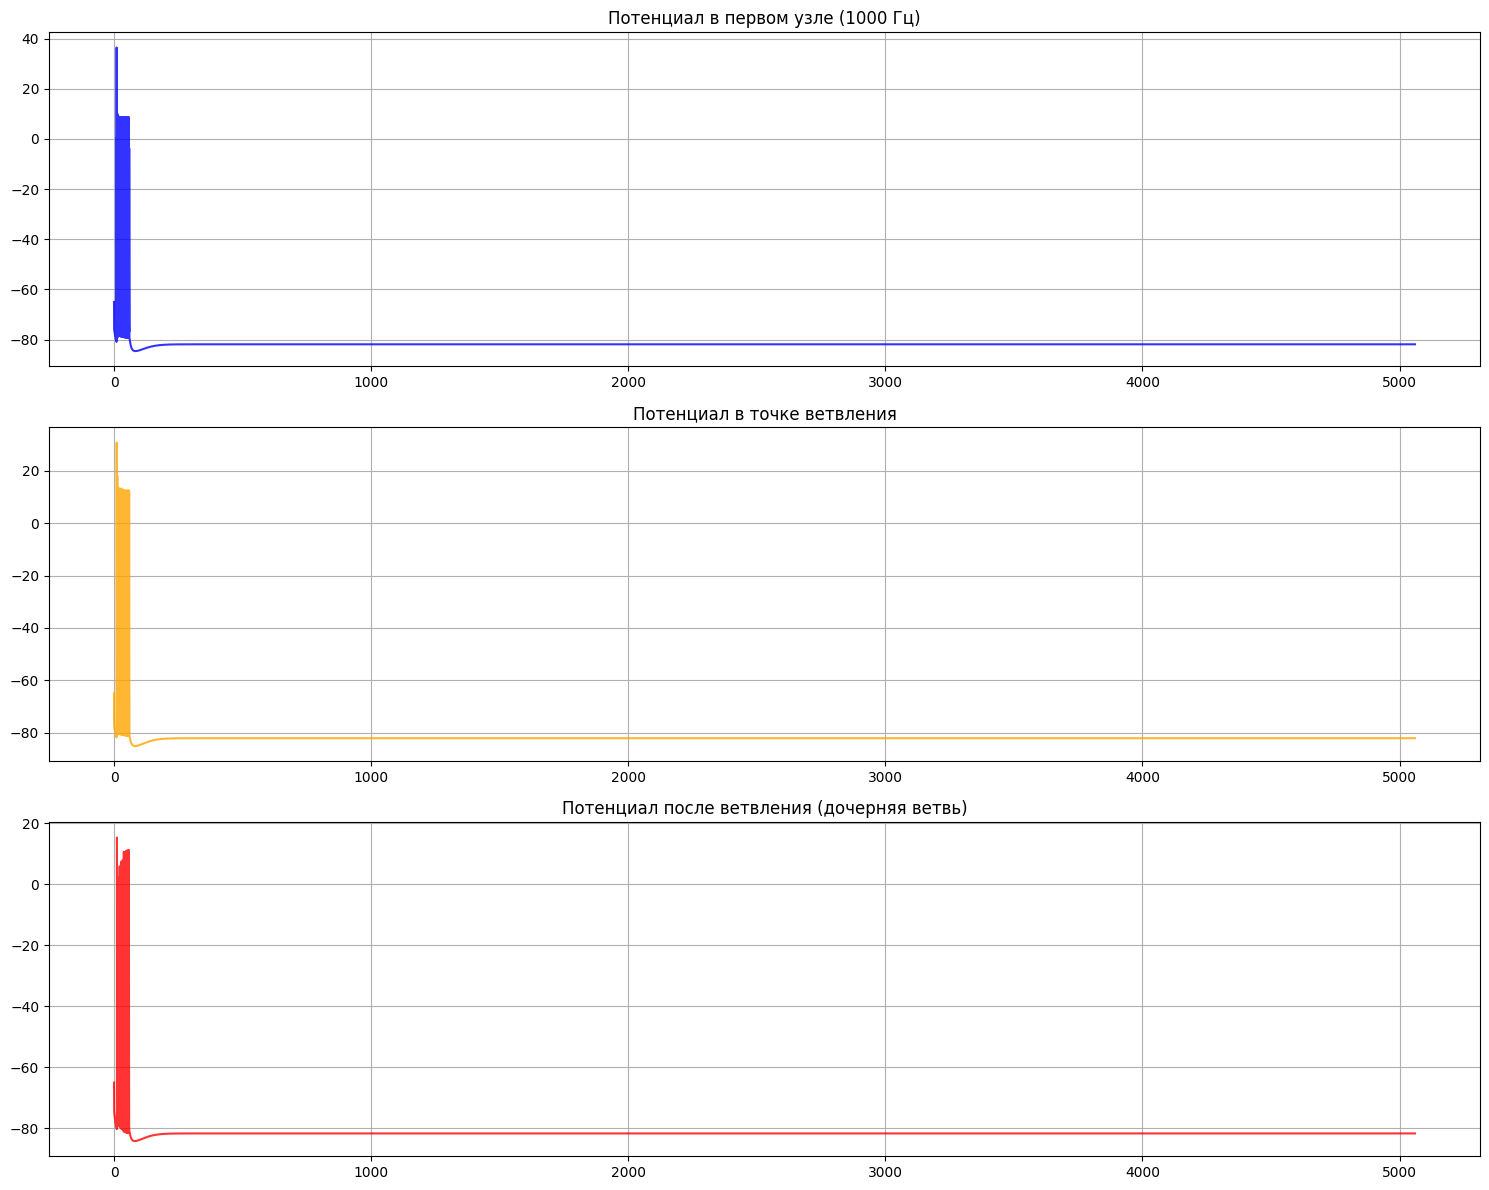

In [51]:
def analyze_single_frequency(main_axon, nodes_dist, branch_nodes, freq, amp=1.0, num_pulses=50):
    """Анализирует проведение на одной частоте и возвращает детальные данные"""

    # Расчет параметров стимуляции
    T_ms = 1000.0 / freq
    ton = 0.1
    toff = T_ms - ton

    # Создаем стимулятор
    ipulse_stimulator = Ipulse1Stimulator(main_axon[0], position=0.5)
    ipulse_stimulator.set_parameters(del_val=10, ton=ton, toff=toff, num=num_pulses, amp=amp)

    total_time = 10 + num_pulses * (ton + toff) + 100
    h.tstop = total_time

    # Запись потенциалов во всех узлах для детального анализа
    record_v = []
    record_t = h.Vector().record(h._ref_t)

    for i, node_section in enumerate(main_axon):
        vec = h.Vector().record(node_section(0.5)._ref_v)
        record_v.append(vec)

    h.finitialize(-80.0)
    h.run()

    # Преобразование данных
    time_array = np.array(record_t)
    voltage_matrix = np.vstack([np.array(v) for v in record_v])

    return {
        'frequency': freq,
        'time_array': time_array,
        'voltage_matrix': voltage_matrix,
        'stimulator': ipulse_stimulator
    }

# Пример использования для одной частоты:
detailed_data = analyze_single_frequency(
    main_axon=main_axon,
    nodes_dist=nodes_dist,
    branch_nodes=branch_nodes,
    freq=1000  # 1000 Гц
)

# Построение детальных графиков для одной частоты
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

first_node_voltage = detailed_data['voltage_matrix'][0]
branch_voltage = detailed_data['voltage_matrix'][nodes_dist]
branch_axon_voltage = detailed_data['voltage_matrix'][nodes_dist + branch_nodes + 2]

axes[0].plot(detailed_data['time_array'], first_node_voltage, 'b-', alpha=0.8)
axes[0].set_title(f'Потенциал в первом узле ({detailed_data["frequency"]} Гц)')
axes[0].grid(True)

axes[1].plot(detailed_data['time_array'], branch_voltage, 'orange', alpha=0.8)
axes[1].set_title('Потенциал в точке ветвления')
axes[1].grid(True)

axes[2].plot(detailed_data['time_array'], branch_axon_voltage, 'r-', alpha=0.8)
axes[2].set_title('Потенциал после ветвления (дочерняя ветвь)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [18]:
print(branch_point_id, before_branch_id, after_branch_main_id, after_branch_daughter_id)

[node_10(0.5), node_44(0.5)] [node_8(0.5), node_42(0.5)] [node_36(0.5), node_70(0.5)] [node_15(0.5), node_49(0.5)]


In [1]:
# После h.run() и записи потенциалов:

# Создаем полный список всех секций (main_axon + все дочерние ветви)
all_sections = list(main_axon)

# Находим все дочерние секции из terminals и добавляем их
for terminal in terminals:
    # Получаем все секции, начиная от терминала
    current_sec = terminal
    while current_sec:
        if current_sec not in all_sections:
            all_sections.append(current_sec)
        # Переходим к следующей секции в цепи
        children = list(current_sec.children())
        next_sec = None
        for child in children:
            if child not in all_sections:
                next_sec = child
                break
        current_sec = next_sec

# Создаем словарь для быстрого поиска индексов по ВСЕМ секциям
node_name_to_index = {}
for i, node in enumerate(all_sections):
    node_name_to_index[node.name()] = i

print(f"Всего секций в словаре: {len(node_name_to_index)}")
print("Доступные секции:", list(node_name_to_index.keys())[:10])  # первые 10

# Функция для получения индексов СЕГМЕНТОВ
def get_segment_indices(segment_list):
    indices = []
    for segment in segment_list:
        sec = segment.sec
        idx = node_name_to_index.get(sec.name())
        if idx is not None:
            indices.append(idx)
        else:
            print(f"Секция {sec.name()} не найдена в общем списке!")
    return indices

# Получаем индексы наших нод
before_indices = get_segment_indices(before_branch_id)
after_main_indices = get_segment_indices(after_branch_main_id)
after_daughter_indices = get_segment_indices(after_branch_daughter_id)
branch_point_indices = get_segment_indices(branch_point_id)

print("Индексы нод:")
print(f"Точки ветвления: {branch_point_indices}")
print(f"До ветвления: {before_indices}")
print(f"После ветвления (основные): {after_main_indices}")
print(f"После ветвления (дочерние): {after_daughter_indices}")

NameError: name 'main_axon' is not defined

In [20]:
# Перезаписываем потенциалы для всех секций
record_v = []
record_t = h.Vector().record(h._ref_t)  # один общий временной вектор

for sec in all_sections:
    vec = h.Vector().record(sec(0.5)._ref_v)
    record_v.append(vec)

h.run()

# Создаем матрицу потенциалов для всех секций
voltage_matrix = np.vstack([np.array(v) for v in record_v])
time_array = np.array(record_t)

print(f"Размерность voltage_matrix: {voltage_matrix.shape}")
print(f"Размерность time_array: {time_array.shape}")

Размерность voltage_matrix: (490, 40001)
Размерность time_array: (40001,)


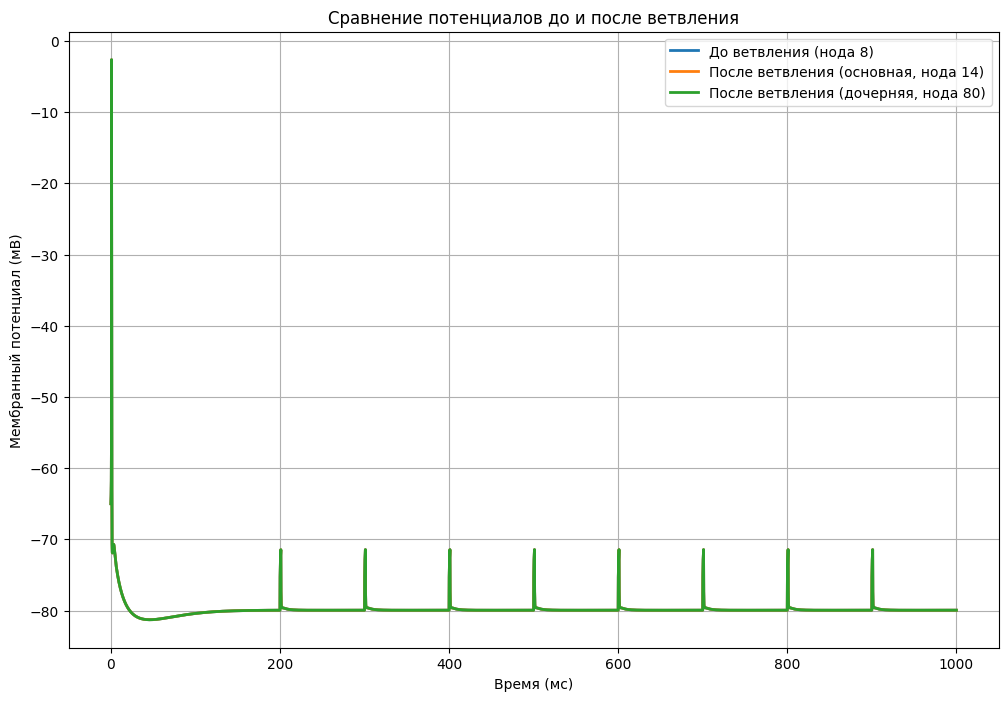

In [31]:
# График 1: Потенциалы на разных группах нод
plt.figure(figsize=(12, 8))

if before_indices and after_main_indices and after_daughter_indices:
    # Берем первые ноды из каждой группы
    before_idx = before_indices[0]
    after_main_idx = after_main_indices[0]
    after_daughter_idx = after_daughter_indices[0]

    plt.plot(time_array, voltage_matrix[before_idx],
             label=f'До ветвления (нода {before_idx})', linewidth=2)
    plt.plot(time_array, voltage_matrix[after_main_idx],
             label=f'После ветвления (основная, нода {after_main_idx})', linewidth=2)
    plt.plot(time_array, voltage_matrix[after_daughter_idx],
             label=f'После ветвления (дочерняя, нода {after_daughter_idx})', linewidth=2)

    plt.legend()
    plt.xlabel("Время (мс)")
    plt.ylabel("Мембранный потенциал (мВ)")
    plt.title("Сравнение потенциалов до и после ветвления")
    plt.grid(True)
    plt.show()

In [30]:
# Функция для обнаружения спайков
def detect_spikes(voltage, time, threshold=0):
    spikes = []
    for i in range(1, len(voltage)-1):
        if voltage[i] > threshold and voltage[i-1] <= threshold and voltage[i] > voltage[i-1]:
            spikes.append(time[i])
    return spikes

# Собираем спайки со всех секций
all_spike_times = []
all_section_indices = []

for i in range(len(all_sections)):
    spikes = detect_spikes(voltage_matrix[i], time_array)
    for spike_time in spikes:
        all_spike_times.append(spike_time)
        all_section_indices.append(i)

# График распространения спайков
plt.figure(figsize=(15, 8))
plt.scatter(all_spike_times, all_section_indices, alpha=0.6, s=10)
plt.xlabel("Время (мс)")
plt.ylabel("Индекс секции")
plt.title("Распространение спайков по всему аксону")
plt.grid(True)

# Добавляем линии для точек ветвления
for branch_idx in branch_point_indices:
    plt.axhline(y=branch_idx, color='red', linestyle='--', alpha=0.5,
                label='Точки ветвления' if branch_idx == branch_point_indices[0] else "")

plt.legend()
plt.show()

IndexError: index 90 is out of bounds for axis 0 with size 90

In [18]:
iclamp = h.IClamp(main_axon[0](0.5))
iclamp.delay = 100
iclamp.dur = 10
iclamp.amp = 0.1
h.finitialize(-80)

h.run()
record_v = []
record_t = []
i = 0
for _ in REG["node"]:
    vec = h.Vector().record(main_axon[i](0.5)._ref_v)
    t = h.Vector().record(h._ref_t)
    record_t.append(t)
    record_v.append(vec)
    i+1
# Пишем потенциал на первом терминале
#t = h.Vector().record(h._ref_t)

h.tstop = 1000.0
#h.finitialize(V_INIT)
h.run()
#time_array = np.array(t)
voltage_matrix = np.vstack([np.array(v) for v in record_v])  # shape: (Nnodes, Nt)
time_matrix = np.vstack([np.array(t) for t in record_t])


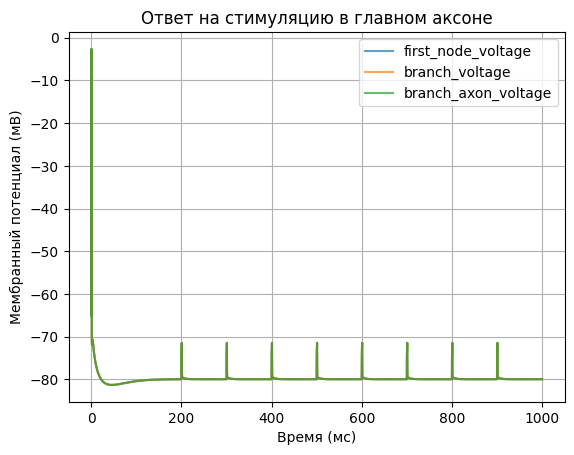

In [29]:
first_node_voltage = voltage_matrix[1]
branch_voltage = voltage_matrix[int(nodes_dist + 4)]
branch_axon_voltage = voltage_matrix[int(nodes_dist + branch_nodes + 4)]

first_node_t = time_matrix[1]
branch_t = time_matrix[int(nodes_dist + 4)]
branch_axon_t = time_matrix[int(nodes_dist + branch_nodes + 4)]

plt.plot(first_node_t,first_node_voltage, alpha=0.7, label= f"first_node_voltage")
plt.plot(branch_t,branch_voltage, alpha=0.7, label= f"branch_voltage")
plt.plot(branch_axon_t,branch_axon_voltage, alpha=0.7, label= f"branch_axon_voltage")


plt.legend()
plt.xlabel("Время (мс)")
plt.ylabel("Мембранный потенциал (мВ)")
plt.title("Ответ на стимуляцию в главном аксоне")
plt.grid(True)
plt.show()

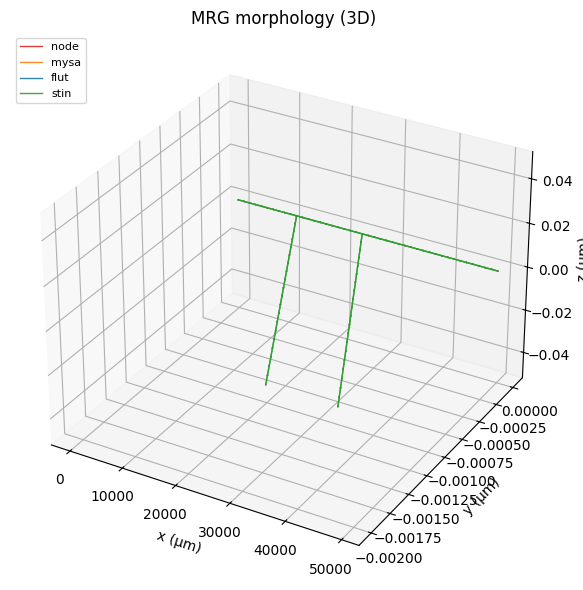

In [123]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from neuron import h

def iter_sections_by_type():
    """Вернёт iterable пар (sec, тип) — пытаемся взять из REG, иначе allsec()."""
    try:
        REG  # если есть глобальный реестр
        for sec in REG.get("node", []): yield sec, "node"
        for sec in REG.get("mysa",  []): yield sec, "mysa"
        for sec in REG.get("flut",  []): yield sec, "flut"
        for sec in REG.get("stin",  []): yield sec, "stin"
        # Если что-то не в REG — добавим остальное, чтобы не потерять:
        reg_set = set(sum((REG.get(k,[]) for k in REG.keys()), []))
        for sec in h.allsec():
            if sec not in reg_set:
                yield sec, "other"
    except NameError:
        # REG нет — берём все секции без типизации
        for sec in h.allsec():
            yield sec, "unknown"

def plot_morphology_3d():
    h.define_shape()
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')

    colors = {
        "node":"C3", "mysa":"C1", "flut":"C0", "stin":"C2",
        "other":"C7", "unknown":"C7"
    }

    for sec, typ in iter_sections_by_type():
        n3d = int(h.n3d(sec=sec))
        if n3d < 2: 
            continue
        xs = [h.x3d(i, sec=sec) for i in range(n3d)]
        ys = [h.y3d(i, sec=sec) for i in range(n3d)]
        zs = [h.z3d(i, sec=sec) for i in range(n3d)]
        ax.plot(xs, ys, zs, linewidth=1.0, alpha=0.9, label=typ if typ not in ax.get_legend_handles_labels()[1] else None, color=colors.get(typ,"k"))

    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_zlabel("z (µm)")
    ax.set_title("MRG morphology (3D)")
    # один раз легенду — по первым встречам типов
    handles, labels = ax.get_legend_handles_labels()
    if labels: ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_morphology_3d()


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from neuron import h

# ---------- 1) Собираем список узлов ----------
def get_all_nodes():
    nodes = []
    # если используешь мой реестр:
    try:
        if "nodes" in REG and REG["nodes"]:
            nodes = list(REG["nodes"])
    except NameError:
        pass
    # fallback: ищем по имени секции
    if not nodes:
        for sec in h.allsec():
            nm = sec.name() if hasattr(sec, "name") else str(sec)
            if nm.startswith("node_"):
                nodes.append(sec)
    # Отсортируем по индексу в имени node_<idx>, чтобы шли по порядку
    def idx(sec):
        m = re.search(r"node_(\d+)", sec.name())
        return int(m.group(1)) if m else 10**9
    nodes.sort(key=idx)
    return nodes

nodes = get_all_nodes()
assert len(nodes) > 0, "Не найдены секции-узлы (node_*)"

# ---------- 2) Запись потенциалов ----------
recordings = []
for sec in nodes:
    vec = h.Vector().record(sec(0.5)._ref_v)
    recordings.append(vec)

t = h.Vector().record(h._ref_t)

# ---------- 3) Запуск симуляции ----------
# (убедиcь, что стим поставлен и tstop задан)
if h.tstop <= 0:
    h.tstop = 100.0
h.run()

# ---------- 4) Преобразуем в numpy ----------
time_array = np.array(t)
voltage_matrix = np.vstack([np.array(v) for v in recordings])  # shape: (Nnodes, Nt)

# ---------- 5) Фигуры: все узлы + теплокарта ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 5a) Все потенциалы
for i, v in enumerate(voltage_matrix):
    ax1.plot(time_array, v, alpha=0.7, label=f"node_{i}")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Voltage (mV)")
ax1.set_title("Potentials at all nodes")
# ax1.legend(ncol=4, fontsize=8)  # включи если узлов немного
ax1.grid(True, ls=':')

# 5b) Спатио-темп. карта (узел по оси Y, время по X)
im = ax2.imshow(
    voltage_matrix,
    aspect='auto',
    extent=[time_array[0], time_array[-1], len(nodes)-1, 0],
    cmap='hot'
)
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Node index")
ax2.set_title("Spatio-temporal propagation")
plt.colorbar(im, ax=ax2, label='Voltage (mV)')

plt.tight_layout()
plt.show()

# ---------- 6) (Опционально) анимация теплокарты ----------
# Покажем «бегущий вертикальный курсор» по времени на теплокарте
fig2, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.imshow(
    voltage_matrix,
    aspect='auto',
    extent=[time_array[0], time_array[-1], len(nodes)-1, 0],
    cmap='hot'
)
cursor, = ax.plot([time_array[0], time_array[0]], [len(nodes)-1, 0], 'w-', lw=1.5)
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Node index"); ax.set_title("Propagation (animated)")

def update(frame):
    x = time_array[frame]
    cursor.set_data([x, x], [len(nodes)-1, 0])
    return (cursor,)

ani = FuncAnimation(fig2, update, frames=len(time_array), interval=10, blit=True)
plt.show()


In [118]:
# Функция для вывода информации о всех сегментах
def print_section_info():
    for sec in h.allsec():
        print(f"Section: {sec.name()}")
        print(f"  nseg: {sec.nseg}")
        print(f"  L: {sec.L} μm")
        print(f"  diam: {sec.diam} μm")
        for seg in sec:
            print(f"  Segment at {seg.x}:")
            print(f"    v: {seg.v} mV")
            print(f"    area: {seg.area()} μm²")

# Вызов функции для просмотра структуры
print_section_info()

Section: node_0
  nseg: 1
  L: 1.0 μm
  diam: 3.3 μm
  Segment at 0.5:
    v: -69.34048640481141 mV
    area: 10.367255756846317 μm²
Section: MYSA_0
  nseg: 1
  L: 3.0 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -66.52289783657656 mV
    area: 94.24777960769379 μm²
Section: FLUT_0
  nseg: 1
  L: 46.0 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -57.561244396942044 mV
    area: 1445.132620651305 μm²
Section: STIN_0
  nseg: 1
  L: 175.16666666666666 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -73.96001037956977 mV
    area: 5503.023131538121 μm²
Section: STIN_1
  nseg: 1
  L: 175.16666666666666 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -77.54392659402384 mV
    area: 5503.023131538121 μm²
Section: STIN_2
  nseg: 1
  L: 175.16666666666666 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -78.06060656923661 mV
    area: 5503.023131538121 μm²
Section: STIN_3
  nseg: 1
  L: 175.16666666666666 μm
  diam: 10.0 μm
  Segment at 0.5:
    v: -78.1285137968023 mV
    area: 5503.023131538121 μm²
Section: